# Prédiction de la druggabilité de poches protéiques

Les poches protéiques constituent les régions structurales susceptibles d'accueillir des ligands. Leur composition physicochimique, leur taille et leur géométrie peuvent être liées à leur capacité à fixer un candidat médicament, c'est-à-dire à leur druggabilité.

Dans ce projet on cherche à déterminer **si les descripteurs d'une poche ligand-based permettent de prédire sa druggabilité**.

- Autrices: Laurédane Coustillas, Farah-Luna Gonzalez, Anna Perova
- Étudiantes de M2 BI-ISDD - Modélisation des macromolécules
- Date: 21/09/2026 - 26/09/2026

- Étapes:
    1. Pré-processing & Analyse de dataset
    2. Clustering
    3. Bootstrap
    4. CART pour minimiser l'erreur
    5. RF et Gradiant Boosting
    6. PLS ou PLSDA

- Info sur dataset:
    - L'ensemble de données a été extrait du jeu de données de Krasowski et contient 400 poches :
        - 316 poches druggables,
        - 84 poches moins druggables.

Decrit selon 19 variables:
-   descripteurs quantitatifs de la géométrie de la poche: `hydrophobic_kyte`, `p_hydrophobic_residue`, `p_polar_residues`, `p_aromatic_residues`, `p_aliphatic_residues`, `p_Otyr_atom`,  `p_NE2_atom`, `p_Nlys_atom`, `p_Ntrp_atom`, `p_Ooh_atom`, `p_ND1_atom`,  `SURFACE_HULL`, `DIAMETER_HULL`, `VOLUME_HULL`, `SMALLEST_SIZE`,  `RADIUS_CYLINDER`, `C_RESIDUES`, `NumAtoms_atm`, `Radius_of_gyration_atm`;
-   descripteurs qualitatif: `Shape` (4 types/facteurs: Sphere, Disk, Strongly anisotropic, Rod) d'après *Ziani et al., 2026*;

Variables à prédire: 
-   Druggabilité (qualitative) = le type de druggabilité de chaque poche : 1 = druggable, 0 = moins druggable (Col 24);
-   Score_Drugg (quantitative) = score de druggabilité (Col 3).


- Packages utilisés:
    - `FactoMineR`,
    - `factoextra`,
    - `corrplot`,
    - `gplots`,
    - `pheatmap`,
    - `caret`,
    - `pROC`,
    - `fmsb`,
    - `rpart`,
    - `MASS`,
    -`rpart.plot`,
    - `randomForest`, 
    - `dplyr`


#### 1. Intallation des packages et chargement du dataset

In [23]:
required_packages <- c("FactoMineR","factoextra","corrplot","gplots",
"pheatmap","caret","pROC","fmsb","rpart","MASS","rpart.plot","randomForest", "dplyr")
lapply(required_packages, require, character.only = TRUE)

file <- read.csv("data.csv")
glimpse(file)
dim(file)
# Vérifier si les NA sont présents
file_na <- na.omit(file)
dim(file_na)
# Transformer la variable `Shape` en factor
file_na$Shape <- as.factor(file_na$Shape)

Rows: 400
Columns: 23
$ PDB_ID                 <chr> "PDB1", "PDB2", "PDB3", "PDB4", "PD…
$ Ligand_Num             <int> 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, …
$ Score_Drugg            <dbl> 0.66, 0.91, 0.94, 0.65, 0.83, 0.92,…
$ hydrophobic_kyte       <dbl> -0.48, 0.22, -0.17, -0.79, 0.01, 0.…
$ p_hydrophobic_residues <dbl> 0.62, 0.83, 0.82, 0.50, 0.76, 0.78,…
$ p_polar_residues       <dbl> 0.59, 0.56, 0.45, 0.57, 0.52, 0.52,…
$ p_aromatic_residues    <dbl> 0.16, 0.17, 0.36, 0.29, 0.12, 0.13,…
$ p_aliphatic_residues   <dbl> 0.19, 0.39, 0.14, 0.14, 0.28, 0.26,…
$ p_Otyr_atom            <dbl> 0.02, 0.00, 0.01, 0.03, 0.01, 0.00,…
$ p_NE2_atom             <dbl> 0.00, 0.00, 0.02, 0.00, 0.00, 0.02,…
$ p_Nlys_atom            <dbl> 0.00, 0.02, 0.01, 0.00, 0.02, 0.02,…
$ p_Ntrp_atom            <dbl> 0.01, 0.00, 0.00, 0.01, 0.00, 0.00,…
$ p_Ooh_atom             <dbl> 0.03, 0.00, 0.01, 0.01, 0.02, 0.02,…
$ p_ND1_atom             <dbl> 0.00, 0.00, 0.02, 0.00, 0.00, 0.02,…
$ SURFACE_HULL           <

#### 2. Ajouter la variable à prédire : Druggabilité 
- Si `Score_Drugg` > 0.5 -> "Druggable"
- Sinon: "Non-Druggable"

In [22]:
file_na$druggable <- if_else(file$Score_Drugg > 0.5, "Druggable", "Non-Druggable")

#### 3. Mise à l'échelle
- Énlèver la variable `Score_Drugg`et autres variables non-numeriques pour mettre les numeriques à l'échelle
- Faire un plot avant/après pour comparer

In [13]:
file_wo_drug <- file_na[-3]
data <- file_na[4:22]
data_raw <- data
data_s <- as.data.frame(scale(data))

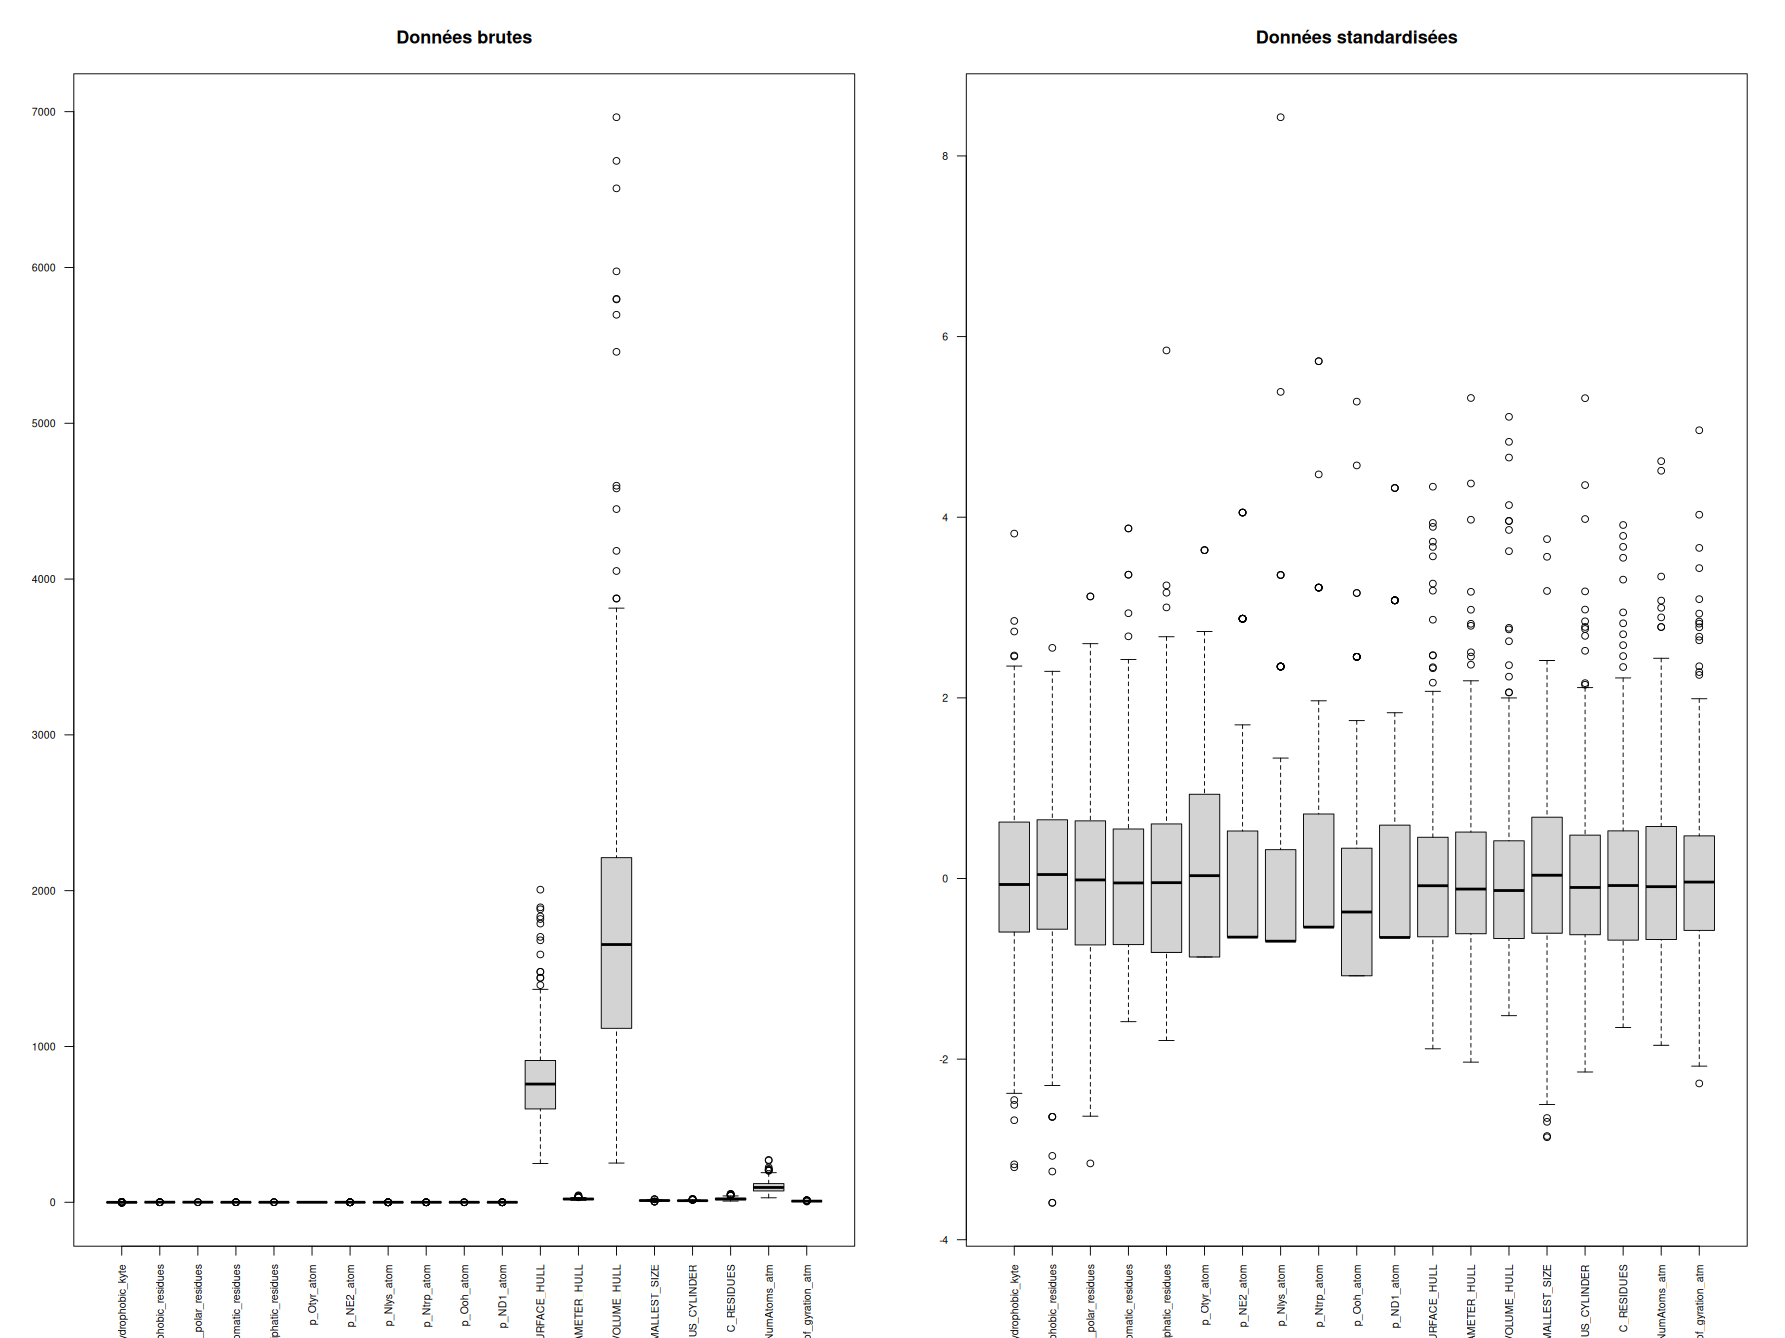

In [19]:
par(mfrow = c(1, 2))
boxplot(data_raw, main = "Données brutes", las = 2, cex.axis = 0.7)
data_s <- as.data.frame(scale(data))
boxplot(data_s, main = "Données standardisées", las = 2, cex.axis = 0.7)
par(mfrow = c(1, 1))

*Observations: `SURFACE_HULL` et `VOLUME_HULL` sont les plus importants due à la difference des unités avec le reste des variables; Le `scale()` permet de tous normaliser. On note un outlier pour `p_Nlys_atom`, c'est possible qu'il faut l'énlever.*

#### 4. Vérification de correlations entre le variables & Plot la matrice de correlations

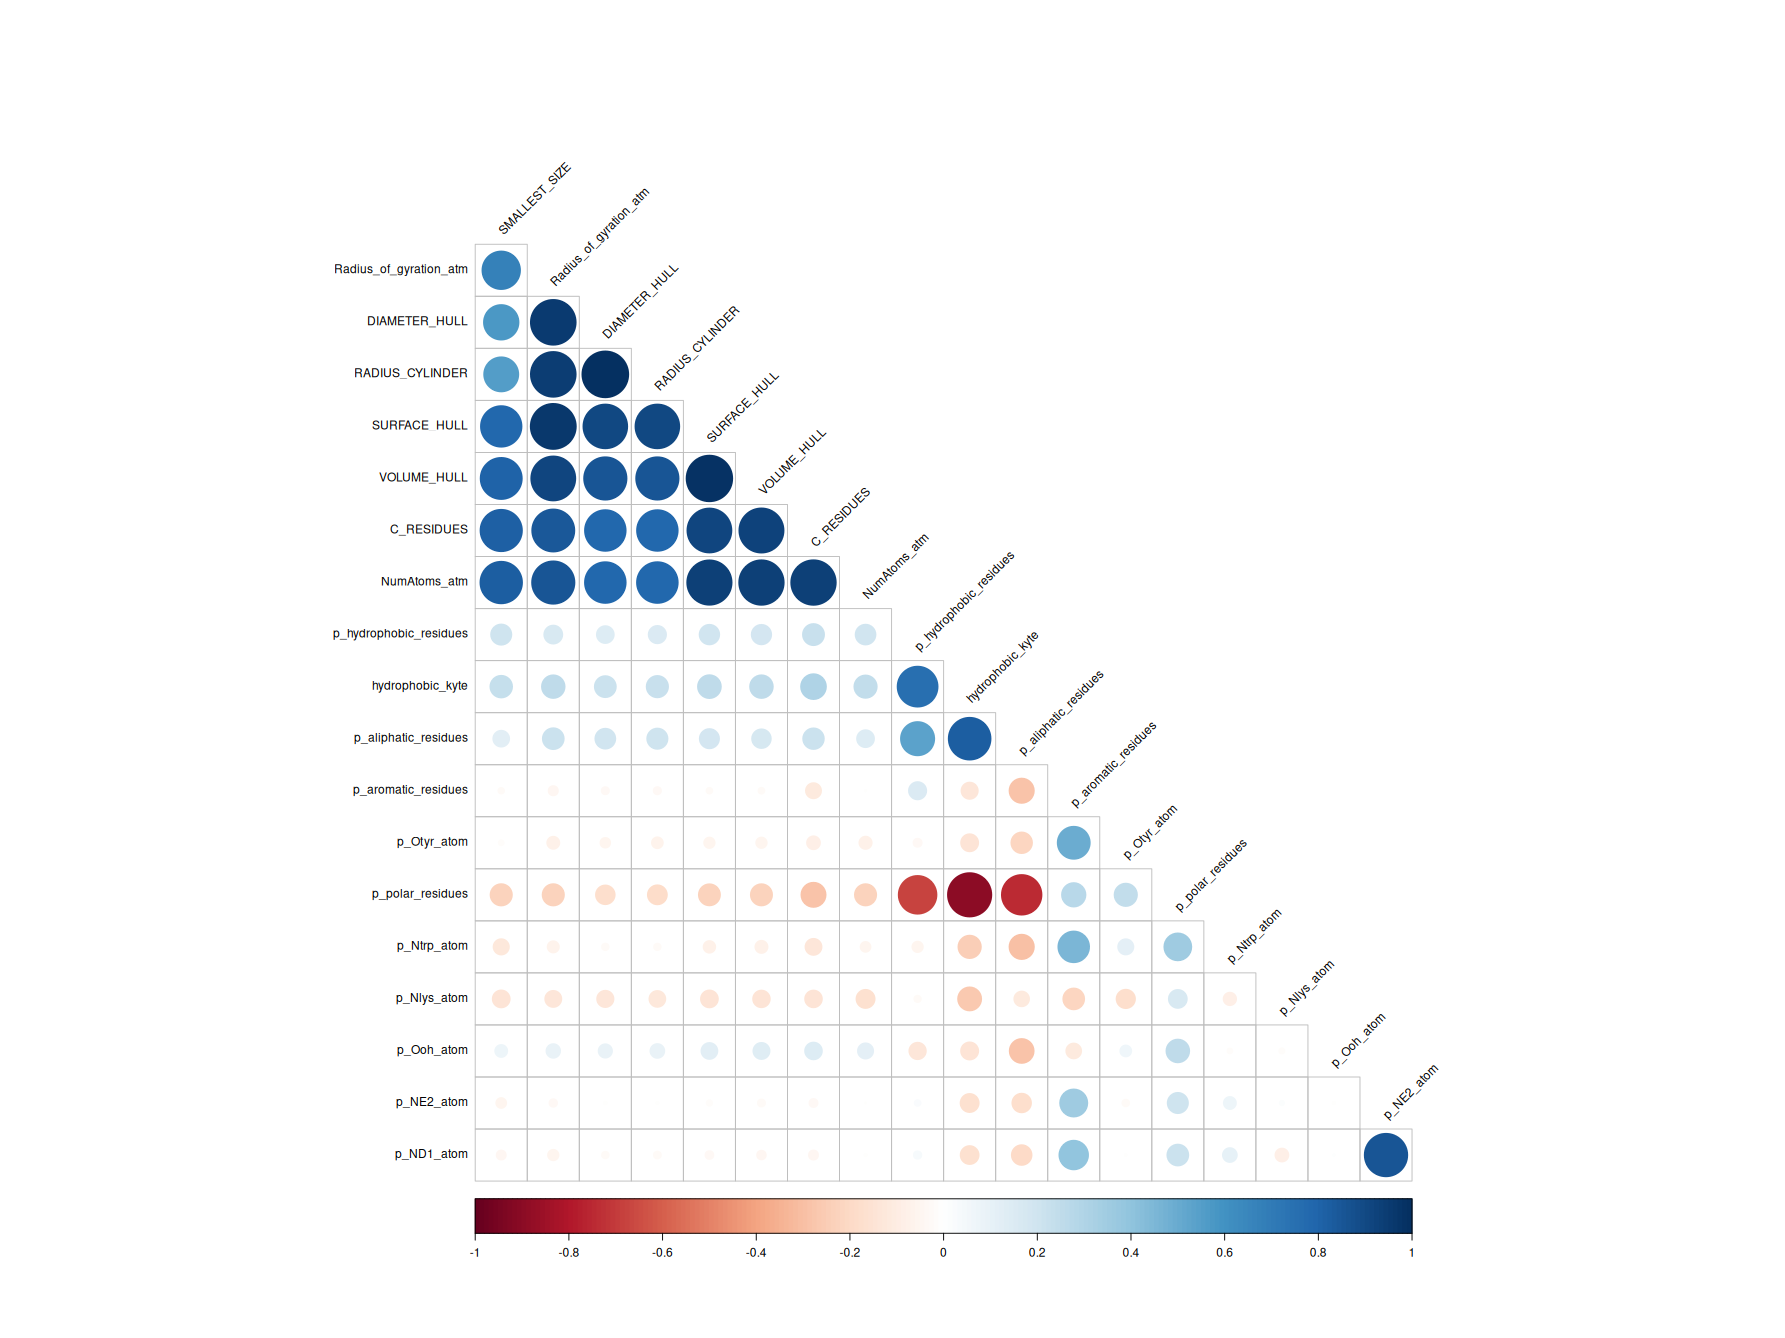

In [18]:
corr_matrix <- cor(data_s)
corrplot(corr_matrix, 
         method = "circle",     
         type = "lower",        
         order = "hclust",      
         tl.col = "black",      
         tl.srt = 45,           
         tl.cex = 0.8,          
         diag = FALSE)


### 5. Vérifier si les variances sont proches à zero

In [15]:
nearZeroVar(data_s, saveMetrics = TRUE)

                       freqRatio percentUnique zeroVar   nzv
hydrophobic_kyte        1.200000         59.75   FALSE FALSE
p_hydrophobic_residues  1.130435         14.25   FALSE FALSE
p_polar_residues        1.933333         17.25   FALSE FALSE
p_aromatic_residues     1.526316         12.25   FALSE FALSE
p_aliphatic_residues    1.263158         12.50   FALSE FALSE
p_Otyr_atom             1.395161          1.50   FALSE FALSE
p_NE2_atom              2.525253          1.25   FALSE FALSE
p_Nlys_atom             1.887931          1.75   FALSE FALSE
p_Ntrp_atom             3.958333          1.50   FALSE FALSE
p_Ooh_atom              1.130841          2.25   FALSE FALSE
p_ND1_atom              2.436893          1.25   FALSE FALSE
SURFACE_HULL            2.000000         99.75   FALSE FALSE
DIAMETER_HULL           1.000000         86.75   FALSE FALSE
VOLUME_HULL             1.000000        100.00   FALSE FALSE
SMALLEST_SIZE           1.000000         77.00   FALSE FALSE
RADIUS_CYLINDER         

#### 6. Calculer la distance euclidienne

In [26]:
dts.euc <- dist(data_s, method = "euclidean")